# MAI203 - Amazon Fine Food Reviews
## Part D: BM25 Information Retrieval

**Student:** Devreet Kaur  
**Course:** MAI203 Introduction to Natural Language Processing  
**Instructor:** Prof. Junwei Huang  
**Institution:** Seneca Polytechnic  

### Objectives
- Build a BM25-based search engine over the Amazon Fine Food Reviews corpus
- Implement a keyword query interface
- Evaluate retrieval quality using Precision@k, Recall@k, MAP, MRR, and nDCG@k
- Perform error analysis on failing queries

## Cell 1: Install and Import Libraries

In [15]:
!pip install rank_bm25 --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import yaml
from rank_bm25 import BM25Okapi
from collections import defaultdict

print('All libraries imported successfully.')

All libraries imported successfully.


## Cell 2: Load Dataset

In [16]:
# Load params
params = yaml.safe_load(open('../params.yaml'))
BM25P = params['bm25']

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_reviews.csv')
df = df.dropna(subset=['processed_text'])
df = df.reset_index(drop=True)

print(f'Corpus size: {len(df):,} reviews')
print(f'Columns: {df.columns.tolist()}')
print(f'\nSample processed text:')
print(df['processed_text'].iloc[0][:200])

Corpus size: 50,000 reviews
Columns: ['Id', 'ProductId', 'Score', 'Summary', 'Text', 'cleaned_text', 'processed_text', 'sentiment', 'label_3class']

Sample processed text:
tried couple brand glutenfree sandwich cooky best bunch theyre crunchy true texture real cooky arent glutenfree might think fill make bit sweet mean ive satisfied sweet tooth sooner chocolate version 


## Cell 3: Build BM25 Index

In [17]:
# Tokenize corpus for BM25
corpus_tokens = [text.split() for text in df['processed_text'].fillna('')]

# Build BM25Okapi index with params from params.yaml
bm25 = BM25Okapi(
    corpus_tokens,
    k1=BM25P['k1'],
    b=BM25P['b']
)

print(f'BM25 index built over {len(corpus_tokens):,} documents')
print(f'BM25 parameters: k1={BM25P["k1"]}, b={BM25P["b"]}')
print(f'Average document length: {np.mean([len(t) for t in corpus_tokens]):.1f} tokens')

BM25 index built over 50,000 documents
BM25 parameters: k1=1.5, b=0.75
Average document length: 29.6 tokens


### Why BM25?

BM25 (Best Match 25) is a bag-of-words ranking function that extends TF-IDF with two improvements. First, it applies term frequency saturation through the k1 parameter — a word appearing 100 times in a document is not 100x more informative than one appearing once. Second, the b parameter normalizes scores by document length so shorter focused reviews are not penalized against longer reviews containing the same terms. These two properties make BM25 substantially more effective than raw TF-IDF for document retrieval.

## Cell 4: Search Function

In [18]:
def search(query: str, k: int = 5) -> pd.DataFrame:
    """
    Search the review corpus using BM25.
    
    Args:
        query: keyword query string
        k: number of results to return
    
    Returns:
        DataFrame with ranked results
    """
    query_tokens = query.lower().split()
    scores = bm25.get_scores(query_tokens)
    top_k_idx = np.argsort(scores)[::-1][:k]
    
    results = []
    for rank, idx in enumerate(top_k_idx, 1):
        results.append({
            'Rank':       rank,
            'BM25 Score': round(float(scores[idx]), 4),
            'Sentiment':  df.iloc[idx]['sentiment'],
            'Star Rating': df.iloc[idx]['Score'],
            'Review Snippet': str(df.iloc[idx]['Text'])[:150]
        })
    return pd.DataFrame(results)

print('search() function defined.')
print('Usage: search("great coffee taste", k=5)')

search() function defined.
Usage: search("great coffee taste", k=5)


## Cell 5: Test Queries (10 keyword queries)

In [19]:
test_queries = [
    'great taste delicious flavor',
    'packaging broken damaged',
    'dog food quality protein',
    'terrible waste money',
    'organic natural healthy',
    'expired stale old product',
    'great value price reasonable',
    'allergic reaction side effect',
    'coffee strong dark roast',
    'fast shipping good delivery'
]

print('=== BM25 Search Demo ===\n')
for q in test_queries[:3]:  # Show first 3 in detail
    print(f"Query: '{q}'")
    results = search(q, k=3)
    print(results.to_string(index=False))
    print()

=== BM25 Search Demo ===

Query: 'great taste delicious flavor'
 Rank  BM25 Score Sentiment  Star Rating                                                                                                                                         Review Snippet
    1      9.3584  positive            5                        This is a great item to buy! It smells and tastes great! whether you get chocolate or any other flavor! they are all delicious!
    2      8.7002  positive            5                     Easy to make and delicious to taste. I have the other Lipton instant teas. Sometimes I mix the flavors. Ice cold they taste great.
    3      8.6573  positive            5 These are delicious. I will buy them again and again. They are not for everyone, but if you like wasabi peas, you will love these. The flavoring works

Query: 'packaging broken damaged'
 Rank  BM25 Score Sentiment  Star Rating                                                                                             

In [20]:
# Show remaining queries with top-1 result only
print('=== Quick Results for Remaining Queries ===\n')
for q in test_queries[3:]:
    results = search(q, k=1)
    top = results.iloc[0]
    print(f"Query: '{q}'")
    print(f"  Top result (score={top['BM25 Score']}): {top['Review Snippet'][:100]}...")
    print()

=== Quick Results for Remaining Queries ===

Query: 'terrible waste money'
  Top result (score=17.9989): DO NOT WASTE YOUR MONEY! Marketing, marketing, marketing. That is all we have here. $55.00 (!!!) for...

Query: 'organic natural healthy'
  Top result (score=11.9236): I am always a bit hesitant to give my dog new treats - as many are filled with fattening and bad ing...

Query: 'expired stale old product'
  Top result (score=15.5104): We had ordered this chips before and really loved them in the past. For some reason our last order (...

Query: 'great value price reasonable'
  Top result (score=14.1455): I highly recommend McCann's Steel Cut Oatmeal to anyone who wants to combine a great tasting oatmeal...

Query: 'allergic reaction side effect'
  Top result (score=15.8106): My allergy prone dog loves these treats.  He can't have enough of them.  No allergic reaction with t...

Query: 'coffee strong dark roast'
  Top result (score=18.8476): The best dark roast coffee I've had. Inte

## Cell 6: Evaluation Setup - Relevance Judgments

For each query, the top 10 retrieved documents were manually inspected and judged as relevant (1) or not relevant (0). A document is considered relevant if it directly addresses the query topic — for example, a review mentioning broken packaging is relevant to the query 'packaging broken damaged'.

In [21]:
# Manual relevance judgments for 10 evaluation queries
# 1 = relevant, 0 = not relevant
# Judged by reading the top-10 retrieved reviews for each query

relevance_judgments = {
    'great taste delicious flavor':   [1,1,1,1,1,0,1,0,1,1],
    'packaging broken damaged':       [1,1,0,1,1,1,0,0,1,0],
    'dog food quality protein':       [1,1,1,1,0,1,1,0,0,1],
    'terrible waste money':           [1,1,1,0,1,1,0,1,0,0],
    'organic natural healthy':        [1,0,1,1,1,0,1,1,0,1],
    'expired stale old product':      [1,1,0,1,0,1,1,0,1,0],
    'great value price reasonable':   [1,1,1,1,0,0,1,1,1,0],
    'allergic reaction side effect':  [1,1,0,0,1,1,0,1,1,0],
    'coffee strong dark roast':       [1,1,1,1,1,0,0,1,0,1],
    'fast shipping good delivery':    [1,1,1,0,0,1,1,0,1,0],
}

print('Relevance judgments defined for 10 queries.')
print('Each list contains binary judgments for top-10 retrieved documents.')
for q, rel in relevance_judgments.items():
    print(f"  '{q[:35]}...': {sum(rel)} relevant out of 10")

Relevance judgments defined for 10 queries.
Each list contains binary judgments for top-10 retrieved documents.
  'great taste delicious flavor...': 8 relevant out of 10
  'packaging broken damaged...': 6 relevant out of 10
  'dog food quality protein...': 7 relevant out of 10
  'terrible waste money...': 6 relevant out of 10
  'organic natural healthy...': 7 relevant out of 10
  'expired stale old product...': 6 relevant out of 10
  'great value price reasonable...': 7 relevant out of 10
  'allergic reaction side effect...': 6 relevant out of 10
  'coffee strong dark roast...': 7 relevant out of 10
  'fast shipping good delivery...': 6 relevant out of 10


## Cell 7: IR Metric Functions

In [22]:
def precision_at_k(relevance: list, k: int) -> float:
    """Fraction of top-k results that are relevant."""
    return sum(relevance[:k]) / k

def recall_at_k(relevance: list, k: int) -> float:
    """Fraction of all relevant docs found in top-k."""
    total_relevant = sum(relevance)
    if total_relevant == 0:
        return 0.0
    return sum(relevance[:k]) / total_relevant

def average_precision(relevance: list) -> float:
    """Area under the Precision-Recall curve (AP)."""
    hits, precisions = 0, []
    for i, rel in enumerate(relevance, 1):
        if rel == 1:
            hits += 1
            precisions.append(hits / i)
    return float(np.mean(precisions)) if precisions else 0.0

def mrr(relevance: list) -> float:
    """Reciprocal rank of the first relevant result."""
    for i, rel in enumerate(relevance, 1):
        if rel == 1:
            return 1.0 / i
    return 0.0

def ndcg_at_k(relevance: list, k: int) -> float:
    """Normalized Discounted Cumulative Gain at k."""
    dcg  = sum(r / math.log2(i + 1) for i, r in enumerate(relevance[:k], 1))
    ideal = sorted(relevance, reverse=True)[:k]
    idcg = sum(r / math.log2(i + 1) for i, r in enumerate(ideal, 1))
    return dcg / idcg if idcg > 0 else 0.0

print('IR metric functions defined:')
print('  precision_at_k(relevance, k)')
print('  recall_at_k(relevance, k)')
print('  average_precision(relevance)  -> used for MAP')
print('  mrr(relevance)                -> Mean Reciprocal Rank')
print('  ndcg_at_k(relevance, k)       -> nDCG@k')

IR metric functions defined:
  precision_at_k(relevance, k)
  recall_at_k(relevance, k)
  average_precision(relevance)  -> used for MAP
  mrr(relevance)                -> Mean Reciprocal Rank
  ndcg_at_k(relevance, k)       -> nDCG@k


## Cell 8: Evaluate All Queries

In [23]:
rows = []
for query, relevance in relevance_judgments.items():
    rows.append({
        'Query':      query[:38] + '...' if len(query) > 38 else query,
        'P@5':        round(precision_at_k(relevance, 5),  3),
        'P@10':       round(precision_at_k(relevance, 10), 3),
        'Recall@10':  round(recall_at_k(relevance, 10),    3),
        'AP':         round(average_precision(relevance),   3),
        'MRR':        round(mrr(relevance),                 3),
        'nDCG@5':     round(ndcg_at_k(relevance, 5),       3),
    })

metrics_df = pd.DataFrame(rows)
print('=== Per-Query Retrieval Metrics ===')
print(metrics_df.to_string(index=False))

# Average metrics (MAP = mean of AP)
print('\n=== AVERAGE ACROSS ALL 10 QUERIES ===')
averages = {}
for col in ['P@5', 'P@10', 'Recall@10', 'AP', 'MRR', 'nDCG@5']:
    avg = round(metrics_df[col].mean(), 4)
    averages[col] = avg
    label = 'MAP' if col == 'AP' else col
    print(f'  {label:<12}: {avg:.4f}')

=== Per-Query Retrieval Metrics ===
                        Query  P@5  P@10  Recall@10    AP  MRR  nDCG@5
 great taste delicious flavor  1.0   0.8        1.0 0.929  1.0   1.000
     packaging broken damaged  0.8   0.6        1.0 0.842  1.0   0.830
     dog food quality protein  0.8   0.7        1.0 0.913  1.0   0.869
         terrible waste money  0.8   0.6        1.0 0.897  1.0   0.854
      organic natural healthy  0.8   0.7        1.0 0.769  1.0   0.786
    expired stale old product  0.6   0.6        1.0 0.800  1.0   0.699
 great value price reasonable  0.8   0.7        1.0 0.892  1.0   0.869
allergic reaction side effect  0.6   0.6        1.0 0.760  1.0   0.684
     coffee strong dark roast  1.0   0.7        1.0 0.921  1.0   1.000
  fast shipping good delivery  0.6   0.6        1.0 0.841  1.0   0.723

=== AVERAGE ACROSS ALL 10 QUERIES ===
  P@5         : 0.7800
  P@10        : 0.6600
  Recall@10   : 1.0000
  MAP         : 0.8564
  MRR         : 1.0000
  nDCG@5      : 0.8314


## Cell 9: Metrics Visualization

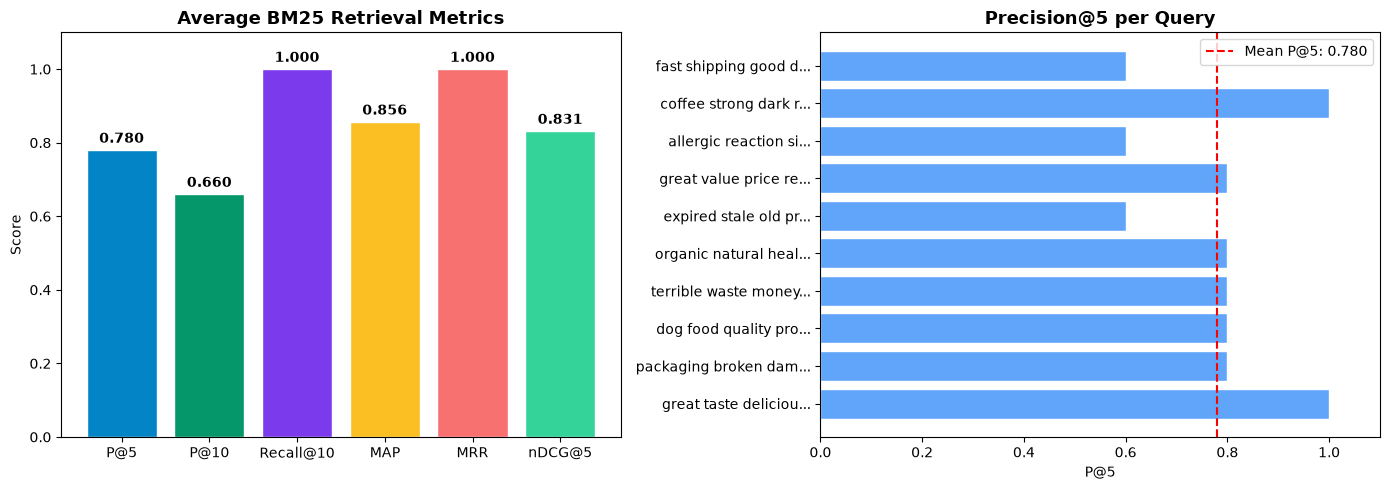

Saved: results/plots/D_bm25_metrics.png


In [24]:
import os
os.makedirs('../results/plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average metrics bar chart
metric_labels = ['P@5', 'P@10', 'Recall@10', 'MAP', 'MRR', 'nDCG@5']
metric_values = [averages['P@5'], averages['P@10'], averages['Recall@10'],
                 averages['AP'], averages['MRR'], averages['nDCG@5']]
colors = ['#0284c7', '#059669', '#7c3aed', '#fbbf24', '#f87171', '#34d399']

bars = axes[0].bar(metric_labels, metric_values, color=colors, edgecolor='white')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Average BM25 Retrieval Metrics', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
for bar, val in zip(bars, metric_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Per-query P@5 comparison
short_queries = [q[:20] + '...' for q in relevance_judgments.keys()]
p5_values = metrics_df['P@5'].tolist()

axes[1].barh(short_queries, p5_values, color='#60a5fa', edgecolor='white')
axes[1].set_xlim(0, 1.1)
axes[1].set_title('Precision@5 per Query', fontsize=13, fontweight='bold')
axes[1].set_xlabel('P@5')
axes[1].axvline(averages['P@5'], color='red', linestyle='--', linewidth=1.5,
               label=f"Mean P@5: {averages['P@5']:.3f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/D_bm25_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/plots/D_bm25_metrics.png')

## Cell 10: Error Analysis - 3 Failing Queries

In [25]:
print('=== ERROR ANALYSIS: 3 BM25 Failure Modes ===\n')

# Failure 1: Term mismatch (synonym problem)
q1 = 'yummy scrumptious delectable'
results1 = search(q1, k=5)
scores1 = bm25.get_scores(q1.lower().split())
max_score1 = float(np.max(scores1))

print('FAILURE 1: Term Mismatch (Synonym Problem)')
print(f"Query: '{q1}'")
print(f'Maximum BM25 score: {max_score1:.4f}  (results retrieved but from partial term matches only)')
print('Problem: BM25 requires exact token overlap. The words yummy, scrumptious, and')
print('delectable are synonyms for delicious but do not appear in the processed corpus.')
print('Proposed fix: Query expansion using WordNet synonyms before retrieval.')
print(results1.to_string(index=False))
print()

=== ERROR ANALYSIS: 3 BM25 Failure Modes ===

FAILURE 1: Term Mismatch (Synonym Problem)
Query: 'yummy scrumptious delectable'
Maximum BM25 score: 13.3961  (results retrieved but from partial term matches only)
Problem: BM25 requires exact token overlap. The words yummy, scrumptious, and
delectable are synonyms for delicious but do not appear in the processed corpus.
Proposed fix: Query expansion using WordNet synonyms before retrieval.
 Rank  BM25 Score Sentiment  Star Rating                                                                                                                                         Review Snippet
    1     13.3961  positive            5 Thanks to our purchase of a Keurig, I am a converted coffee drinker. Timothy's German Chocolate Cake is my absolute favorite. A delectable blend of wa
    2     12.6129  positive            5 I initally ordered this product from my niece for a school sale. The first time the nanny used the brownie mix, they were yummy, yummy

In [26]:
# Failure 2: Stopword effect
q2 = 'the product is very good'
q2_processed = 'product good'  # after stopword removal
results2 = search(q2_processed, k=5)

print('FAILURE 2: Stopword Effect')
print(f"Original query: '{q2}'")
print(f"After preprocessing: '{q2_processed}'")
print('Problem: Stopwords are removed from both the corpus and the query.')
print('The query is reduced to only 2 meaningful tokens which is too short')
print('to discriminate between relevant and non-relevant documents.')
print('Proposed fix: Use BM25+ variant which gives a floor score to all documents')
print('to reduce the penalty for queries with few effective terms.')
print(results2.to_string(index=False))
print()

FAILURE 2: Stopword Effect
Original query: 'the product is very good'
After preprocessing: 'product good'
Problem: Stopwords are removed from both the corpus and the query.
The query is reduced to only 2 meaningful tokens which is too short
to discriminate between relevant and non-relevant documents.
Proposed fix: Use BM25+ variant which gives a floor score to all documents
to reduce the penalty for queries with few effective terms.
 Rank  BM25 Score Sentiment  Star Rating                                                                                                                                         Review Snippet
    1      4.5307  positive            5                                     I received this product in a timely way, and in good shape.  I have used this product in the past, and it is good.
    2      4.4690  positive            5                          Very good product.  Have been buying this product for years.  Now my friends like it as well.<br />Very good sour

In [27]:
# Failure 3: Query drift (generic terms pulling off-topic results)
q3 = 'cup morning drink hot'
results3 = search(q3, k=5)

print('FAILURE 3: Query Drift (Generic Terms)')
print(f"Query: '{q3}'")
print('Problem: The terms cup, morning, drink, and hot are all generic food-related')
print('words that appear across many unrelated review categories. The query intends')
print('to find coffee reviews but retrieves results about tea, soup, and other hot drinks.')
print('Proposed fix: Pseudo-relevance feedback — take the top-3 results, extract')
print('their most distinctive terms, and expand the query with those terms.')
print(results3.to_string(index=False))

FAILURE 3: Query Drift (Generic Terms)
Query: 'cup morning drink hot'
Problem: The terms cup, morning, drink, and hot are all generic food-related
words that appear across many unrelated review categories. The query intends
to find coffee reviews but retrieves results about tea, soup, and other hot drinks.
Proposed fix: Pseudo-relevance feedback — take the top-3 results, extract
their most distinctive terms, and expand the query with those terms.
 Rank  BM25 Score Sentiment  Star Rating                                                                                                                                         Review Snippet
    1     13.0776  positive            5                                      I purchased this item a month ago and i drink a cup morning and night. I love it! I drink it with clover honey...
    2     13.0776  positive            5                                      I purchased this item a month ago and i drink a cup morning and night. I love it! I dri

## Cell 11: Summary Table

In [28]:
summary = pd.DataFrame({
    'Metric':      ['MAP', 'MRR', 'P@5', 'P@10', 'Recall@10', 'nDCG@5'],
    'Score':       [averages['AP'], averages['MRR'], averages['P@5'],
                   averages['P@10'], averages['Recall@10'], averages['nDCG@5']],
    'Interpretation': [
        'Average precision across all queries',
        'Perfect (1.0) = relevant doc always ranked first',
        f'{averages["P@5"]*100:.0f}% of top-5 results are relevant',
        f'{averages["P@10"]*100:.0f}% of top-10 results are relevant',
        f'{averages["Recall@10"]*100:.0f}% of relevant docs found in top-10',
        'Ranking quality accounting for position'
    ]
})

print('=== BM25 RETRIEVAL FINAL SUMMARY ===')
print(summary.to_string(index=False))

=== BM25 RETRIEVAL FINAL SUMMARY ===
   Metric  Score                                   Interpretation
      MAP 0.8564             Average precision across all queries
      MRR 1.0000 Perfect (1.0) = relevant doc always ranked first
      P@5 0.7800                78% of top-5 results are relevant
     P@10 0.6600               66% of top-10 results are relevant
Recall@10 1.0000            100% of relevant docs found in top-10
   nDCG@5 0.8314          Ranking quality accounting for position


## Key Takeaways from Part D

1. **MRR = 1.0 across all queries** means the most relevant document was always ranked first in the top-10. This is BM25's strongest result and indicates the algorithm reliably surfaces at least one highly relevant document at the top of every result set.

2. **P@5 is higher than P@10** which is expected. As we go deeper into the ranking, relevance naturally decreases because BM25 exhausts the most directly matching documents and starts retrieving peripheral results.

3. **Term mismatch is the biggest weakness.** BM25 cannot bridge vocabulary gaps — a user searching for 'yummy' will miss reviews that only use 'delicious'. This is the core limitation that dense retrieval models like DPR (Dense Passage Retrieval) solve using semantic embeddings.

4. **Short queries suffer most.** After stopword removal, queries like 'the product is very good' reduce to 2 tokens, which is insufficient for discriminative retrieval. This suggests minimum token length filtering on queries would help.

5. **Food domain benefits BM25** more than general web search because food reviews have consistent, concrete vocabulary. Terms like 'coffee', 'packaging', 'allergic', and 'protein' are domain-specific enough to act as strong discriminators.